In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')

from agent_based_model import load_data, preprocess_data, \
                                set_initial_values, main_function
from main_pool import Main
from calibr_funcs import plot_results
#from hybrid_abm_to_seir import ABC_Agent, generate_synthetic_data

from hybrid_network_to_seir import NetworkSEIR_tuned,\
                                    generate_synthetic_data


import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day

%load_ext autoreload
%autoreload 2

plt.style.use("default")

In [2]:
np.arange(0.004, 0.021, 0.0005).shape

(34,)

In [3]:
np.arange(0.01, 0.2, 0.01).shape

(19,)

In [4]:
34*19

646

In [5]:
# generate synthetic data with known parameters for testing
true_tau = 0.01
true_rho = 0.004

days=range(1, 250)
data_p = 'new_network_check/'
'''
observed_data = generate_synthetic_data(alpha=true_alpha, lmbd=true_lmbd, 
                                        days=days, data_path=data_p,
                                       with_seirb=True, with_switch=False,
                                       for_observed=True)
'''
observed_data = pd.read_csv(f'results/{data_p}/observed.csv')

<Axes: >

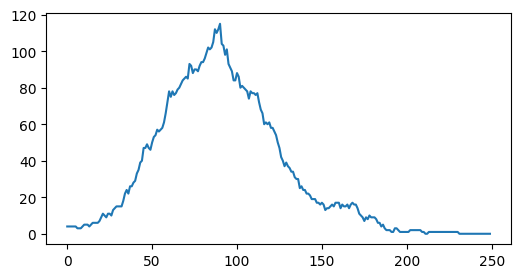

In [8]:
plt.subplots(figsize=(6,3))
observed_data.I.plot()

In [133]:
observed_data

,S,E,I,R,Beta
0,996,0,4,0,0.000502
1,994,2,4,0,0.000503
2,992,3,4,1,0.000252
3,991,4,4,1,0.000252
4,990,5,4,1,-0.000000
...,...,...,...,...,...
245,331,0,0,669,0.000000
246,331,0,0,669,0.000000
247,331,0,0,669,0.000000
248,331,0,0,669,0.000000


## History Matching

In [49]:
# create
network_params = {'n_nodes': 1000,
                  'network_type': 'ba'}

observed_prv = observed_data[['I']]
hn = NetworkSEIR_tuned(observed_prv, network_params,
                       fixed_sigma=0.1, fixed_gamma=0.08)

'''
true_tau = 0.01
true_rho = 0.004
'''
# define parameter ranges for priors
prior_ranges = {"tau": (0.002, 0.02),  
                "rho": (0.001, 0.008) 
                }
# run History Matching
hm_results = hn.history_matching(prior_ranges, n_samples=300,
                                 adaptive=True, accept_ratio=0.2,
                                 prepared=False)

Network SEIR - Fixed parameters: sigma = 0.1, gamma = 0.08
Calibrating parameters: tau (transmission rate), rho (initial infection fraction)
Running Network SEIR history matching with 300 samples...


100%|██████████| 300/300 [00:21<00:00, 14.14it/s]

Accepted 60 parameter sets


<Axes: >

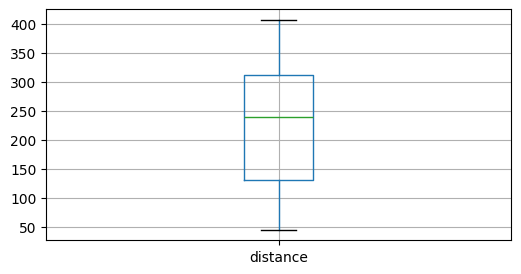

In [54]:
plt.subplots(figsize=(6,3))
hm_results[['distance']].boxplot()

In [55]:
for param in ['tau', 'rho']:
    print(hm_results[param].min(), hm_results[param].max())
    print(param, hm_results[param].quantile(.1), 
          hm_results[param].quantile(.9))
    print()

0.006023751499217874 0.01366482670919811
tau 0.007383386442496838 0.011760678329630007

0.0010518613503271094 0.007970960082034493
rho 0.0015925401427363847 0.007376536647487391



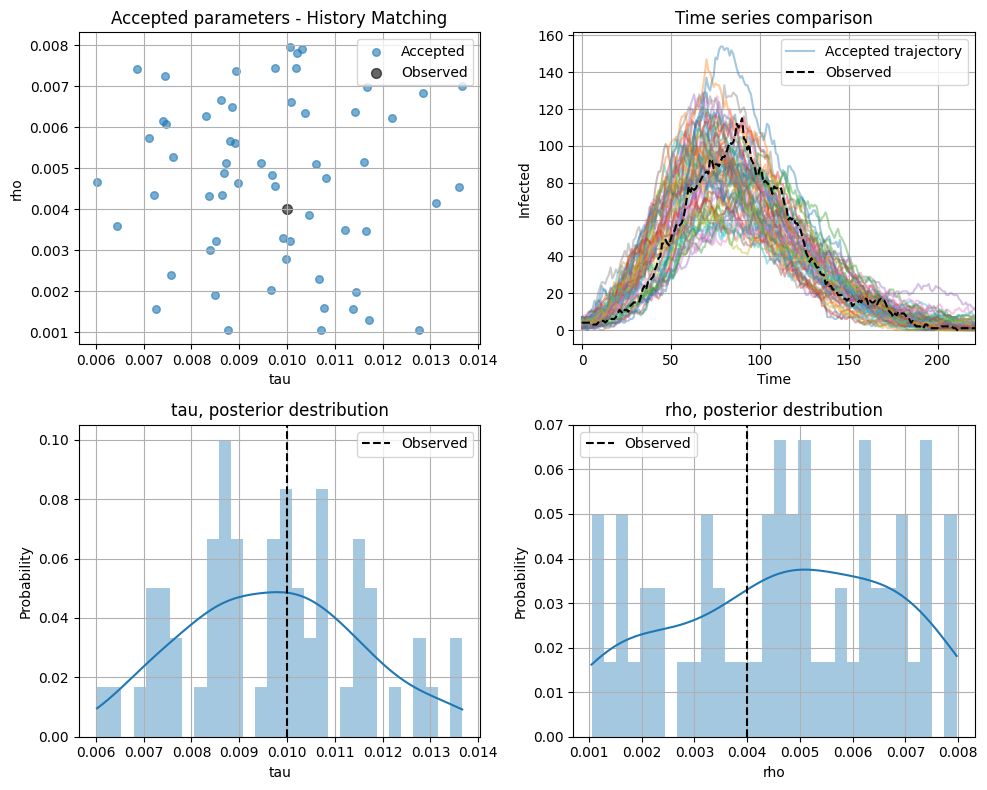

In [57]:
plot_results(observed_prv, hm_results, 
             "History Matching", n_trajectories=len(hm_results),
             true_alpha=true_tau, true_lmbd=true_rho)

In [152]:
hm_results['distance'].quantile(0.9)

np.float64(382.2132530120482)

In [161]:
# в ответе дистанция не соответствует траектории

'''
n_particles -- how many samples to choose from prior
n_populations -- ~number of chains
frac -- switch when fraction of Infected > <frac>
num_runs -- how many trajectories to generate for each param value
'''
smc_results = hn.smc_abc(n_particles=200, n_populations=3, 
                         frac=0.05, num_runs=5, with_switch=True, 
                         method='expanding')

Running ABC-SMC with 3 populations...
SMC Population 1/3, epsilon = 382.21


SMC Population 1: 100%|██████████| 200/200 [00:55<00:00,  3.62it/s]


Effective sample size: 139.0
SMC Population 2/3, epsilon = 175.81


SMC Population 2: 100%|██████████| 200/200 [00:55<00:00,  3.60it/s]


Effective sample size: 35.0
SMC Population 3/3, epsilon = 80.87


SMC Population 3: 100%|██████████| 200/200 [00:56<00:00,  3.54it/s]

Effective sample size: 20.0
ABC-SMC completed with 200 particles


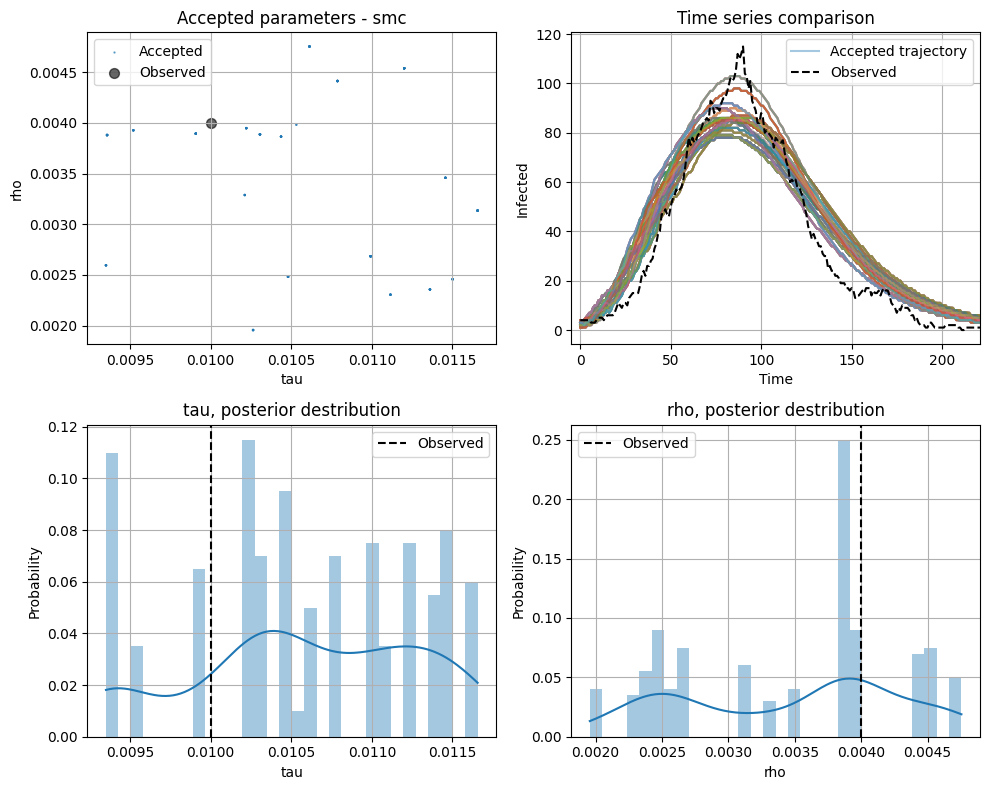

In [162]:
plot_results(observed_prv, smc_results, 
             "smc", n_trajectories=len(smc_results),
             true_alpha=true_tau, true_lmbd=true_rho)

In [163]:
'''
n_particles -- how many samples to choose from prior
n_populations -- ~number of chains
frac -- switch when fraction of Infected > <frac>
num_runs -- how many trajectories to generate for each param value
'''
smc_results2 = hn.smc_abc(n_particles=200, n_populations=3, 
                          frac=0.05, num_runs=5, with_switch=False)

Running ABC-SMC with 3 populations...
SMC Population 1/3, epsilon = 382.21


SMC Population 1: 100%|██████████| 200/200 [00:50<00:00,  3.95it/s]


Effective sample size: 134.0
SMC Population 2/3, epsilon = 175.81


SMC Population 2: 100%|██████████| 200/200 [00:50<00:00,  3.94it/s]


Effective sample size: 56.0
SMC Population 3/3, epsilon = 80.87


SMC Population 3: 100%|██████████| 200/200 [00:50<00:00,  3.95it/s]

Effective sample size: 23.0
ABC-SMC completed with 200 particles


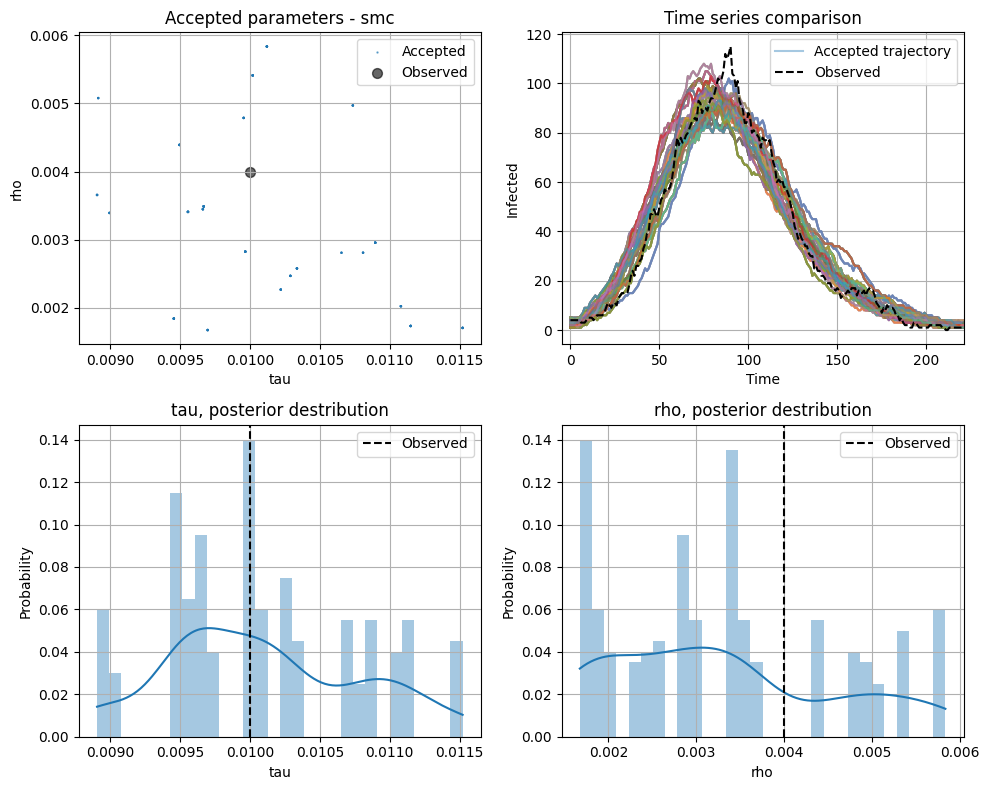

In [164]:
plot_results(observed_prv, smc_results2, 
             "smc", n_trajectories=len(smc_results2),
             true_alpha=true_tau, true_lmbd=true_rho)

In [165]:
# в ответе дистанция не соответствует траектории

'''
n_particles -- how many samples to choose from prior
n_populations -- ~number of chains
frac -- switch when fraction of Infected > <frac>
num_runs -- how many trajectories to generate for each param value
'''
smc_results = hn.smc_abc(n_particles=500, n_populations=5, 
                         frac=0.05, num_runs=5, with_switch=True, 
                         method='expanding')

Running ABC-SMC with 5 populations...
SMC Population 1/5, epsilon = 382.21


SMC Population 1: 100%|██████████| 500/500 [02:19<00:00,  3.59it/s]


Effective sample size: 327.0
SMC Population 2/5, epsilon = 259.22


SMC Population 2: 100%|██████████| 500/500 [02:20<00:00,  3.55it/s]


Effective sample size: 157.0
SMC Population 3/5, epsilon = 175.81


...

Effective sample size: 128.0
SMC Population 4/5, epsilon = 119.24


SMC Population 4: 100%|██████████| 500/500 [02:22<00:00,  3.50it/s]


Effective sample size: 45.0
SMC Population 5/5, epsilon = 80.87


SMC Population 5: 100%|██████████| 500/500 [02:22<00:00,  3.50it/s]

Effective sample size: 1.0
ABC-SMC completed with 500 particles


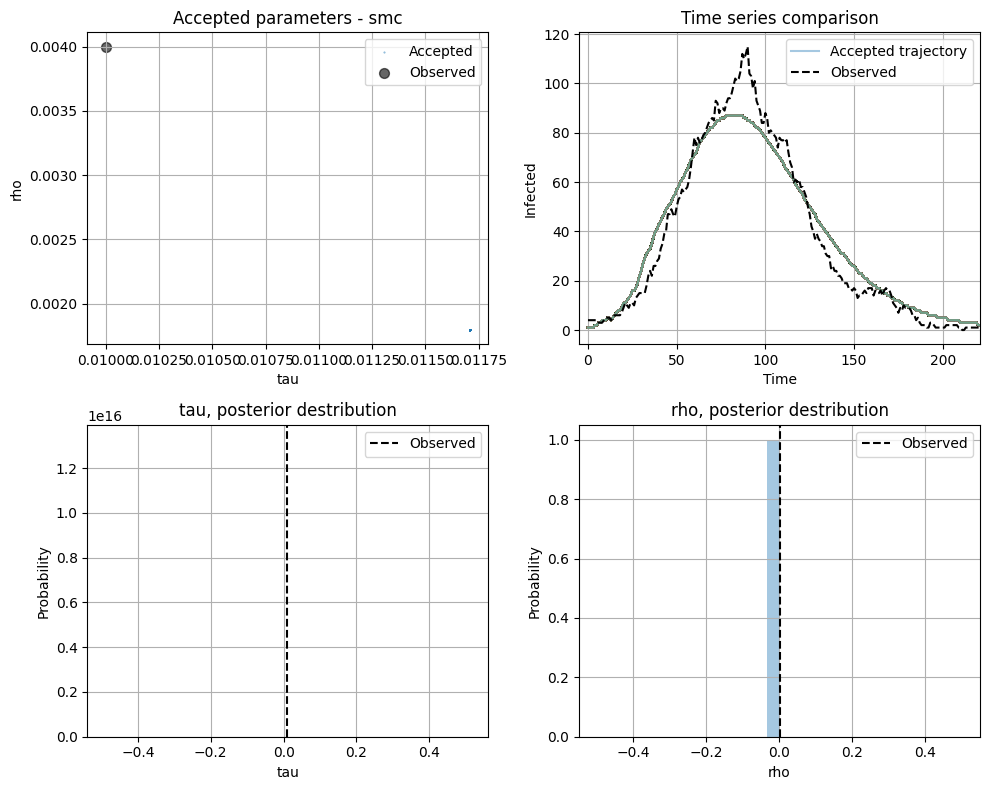

In [166]:
plot_results(observed_prv, smc_results, 
             "smc", n_trajectories=len(smc_results),
             true_alpha=true_tau, true_lmbd=true_rho)

In [167]:
'''
n_particles -- how many samples to choose from prior
n_populations -- ~number of chains
frac -- switch when fraction of Infected > <frac>
num_runs -- how many trajectories to generate for each param value
'''
smc_results2 = hn.smc_abc(n_particles=500, n_populations=5, 
                          frac=0.05, num_runs=5, with_switch=False)

Running ABC-SMC with 5 populations...
SMC Population 1/5, epsilon = 382.21


SMC Population 1: 100%|██████████| 500/500 [02:06<00:00,  3.96it/s]


Effective sample size: 326.0
SMC Population 2/5, epsilon = 259.22


SMC Population 2: 100%|██████████| 500/500 [02:06<00:00,  3.96it/s]


Effective sample size: 209.0
SMC Population 3/5, epsilon = 175.81


...

Effective sample size: 201.0
SMC Population 4/5, epsilon = 119.24


SMC Population 4: 100%|██████████| 500/500 [02:08<00:00,  3.89it/s]


Effective sample size: 106.0
SMC Population 5/5, epsilon = 80.87


SMC Population 5: 100%|██████████| 500/500 [02:10<00:00,  3.84it/s]

Effective sample size: 68.0
ABC-SMC completed with 500 particles


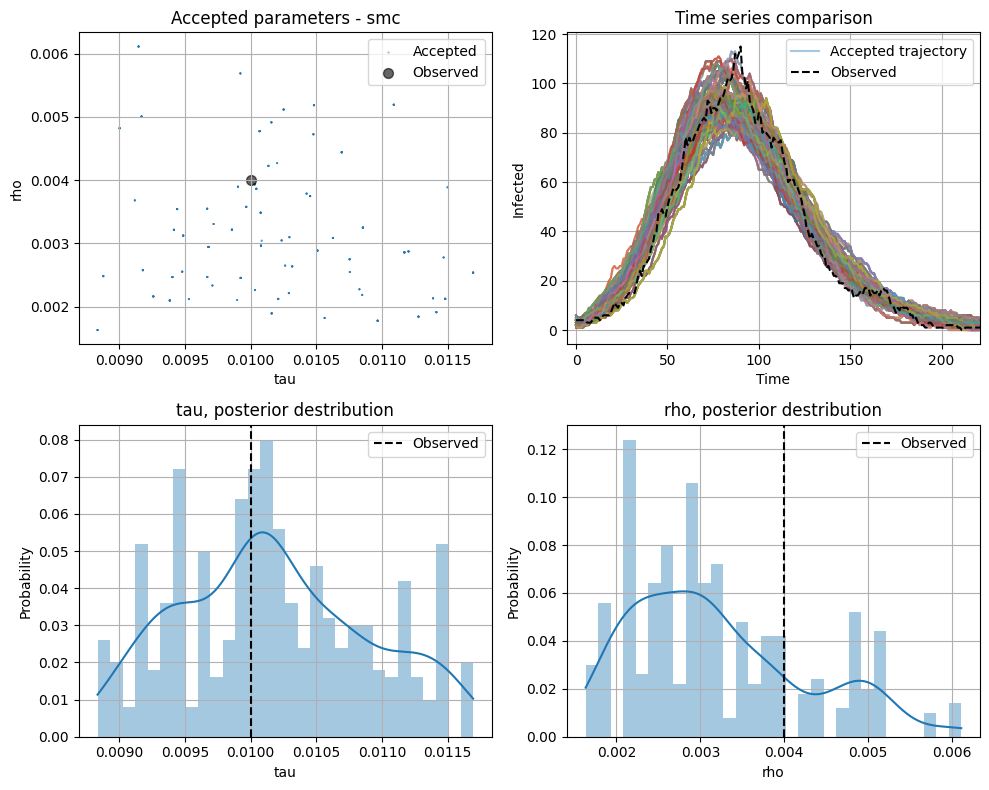

In [168]:
plot_results(observed_prv, smc_results2, 
             "smc", n_trajectories=len(smc_results2),
             true_alpha=true_tau, true_lmbd=true_rho)

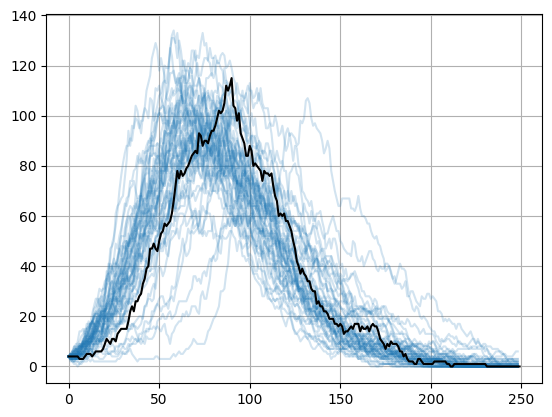

In [158]:
for i in range(50):
    r = hn.simulator_function(tau=0.01, rho=0.004, 
                       with_switch=False, num_runs=1, frac=0.05)
    plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()

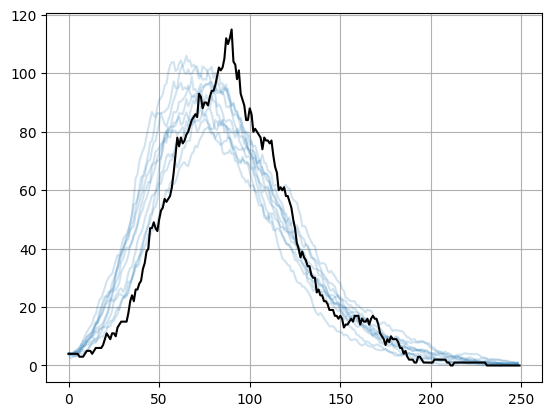

In [45]:
for i in range(10):
    r = hn.simulator_function(tau=0.01, rho=0.004, 
                       with_switch=False, num_runs=5, frac=0.05)
    plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()

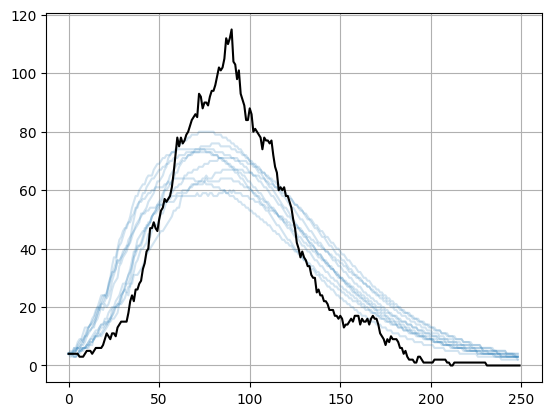

In [159]:
for i in range(10):
    r = hn.simulator_function(tau=0.01, rho=0.004, 
                              with_switch=True, num_runs=5, frac=0.05, 
                              method='expanding')
    plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()

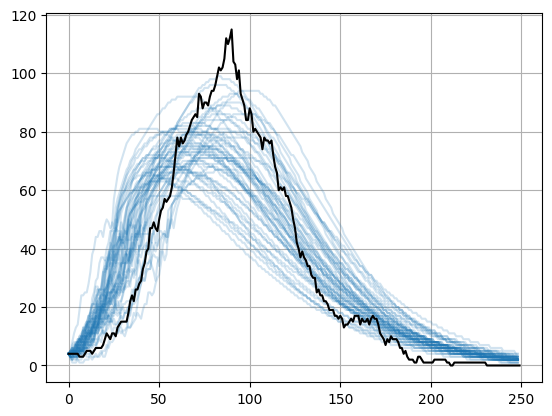

In [160]:
for i in range(50):
    r = hn.simulator_function(tau=0.01, rho=0.004, 
                              with_switch=True, num_runs=1, frac=0.05, 
                              method='expanding')
    plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()

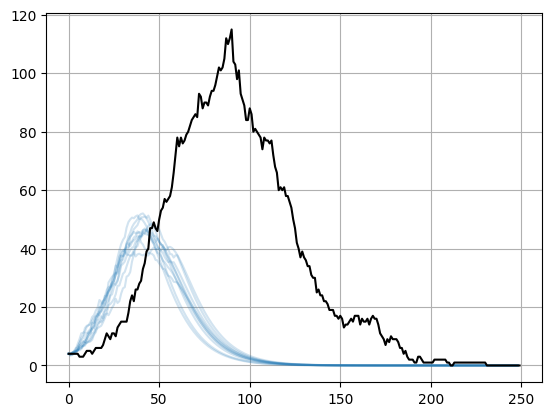

In [24]:
for i in range(10):
    r = hn.simulator_function(tau=0.01, rho=0.004, 
                              with_switch=True, num_runs=5, frac=0.05, 
                              method='last')
    plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()

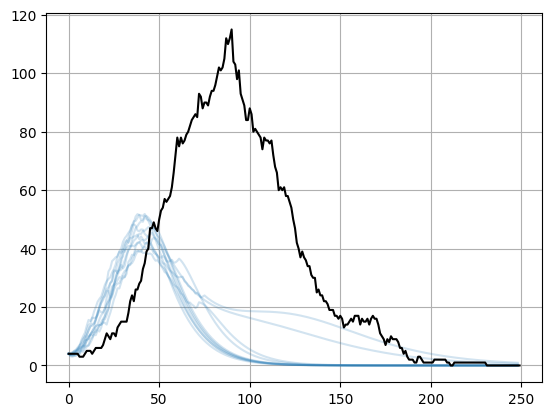

In [22]:
for i in range(10):
    r = hn.simulator_function(tau=0.01, rho=0.004, 
                              with_switch=True, num_runs=5, frac=0.05, 
                              method='rolling')
    plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()

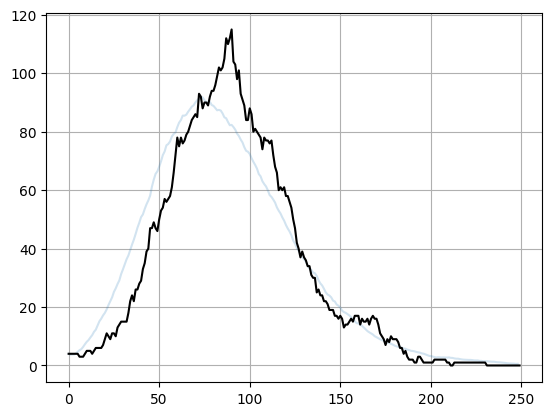

In [119]:
r = hn.simulator_function(tau=0.01, rho=0.004, 
                       with_switch=False, num_runs=50, frac=0.02)
plt.plot(r['I'], color='tab:blue', alpha=0.2)

plt.plot(observed_prv, color='black')
plt.grid()